# NB 00 — Fourier Features from Scratch

**Week 38 · The Frequency Domain.** Companion to
[The Frequency Domain: How Fourier Transforms Secretly Powered Everything We Built](https://artifocial.com/blog/frequency-domain-2026-sep-17)
and to the explainer [Fourier Transforms Explained](https://artifocial.com/blog/fourier-transforms-explained-2026-sep-18).

Pure NumPy and Matplotlib. CPU only. No frameworks, no autodiff library — the MLP's backward pass is
written out by hand and checked against central finite differences, so that nothing in the
spectral-bias result can be blamed on a framework default or a wrong gradient.

**What this notebook establishes, in order:**

1. A plain MLP fitting a two-tone target learns the low tone to within a third of a percent and
   leaves the high tone at a quarter of its true amplitude, still crawling upward. That is spectral bias, measured rather than asserted.
2. Random Fourier features ([Rahimi & Recht, NeurIPS 2007](https://papers.nips.cc/paper_files/paper/2007/hash/013a006f03dbc5392effeb8f18fda755-Abstract.html))
   approximate an RBF kernel, and the error falls at the rate the theory predicts.
3. Bochner's theorem, verified numerically in both directions — including a function that *looks* like
   a kernel, has a negative spectral density, and is duly shown to have an indefinite Gram matrix.
4. Adding a Fourier feature map to the *same* MLP fixes the high tone.
5. The mechanism: the neural tangent kernel goes from non-stationary and wide to stationary and narrow,
   and the feature scale `sigma` is the dial that sets its width.

The last point is the one worth carrying away. Fourier features are not a trick that happens to work;
they are a change of the kernel your network is implicitly doing regression with, and you can measure
that kernel directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

print("python", sys.version.split()[0])
print("numpy ", np.__version__)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

python 3.14.5
numpy  2.5.3


---

## 1. The target, and what "high frequency" means here

Our target is deliberately boring: two pure tones on the unit interval.

$$ f(x) = \sin(2\pi x) \;+\; 0.3\,\sin(2\pi \cdot 15 x) $$

One slow component at amplitude 1.0, one fast component at amplitude 0.3. Because the target is a
sum of sinusoids at integer frequencies on a uniform grid, its discrete Fourier transform has exactly
two non-zero bins, and we know their heights **exactly**. That is the whole reason for choosing it:
it turns "the network learned the coarse structure but not the detail" from an impression into a
number we can print.

target amplitude at f=1  : 1.0000
target amplitude at f=15 : 0.3000


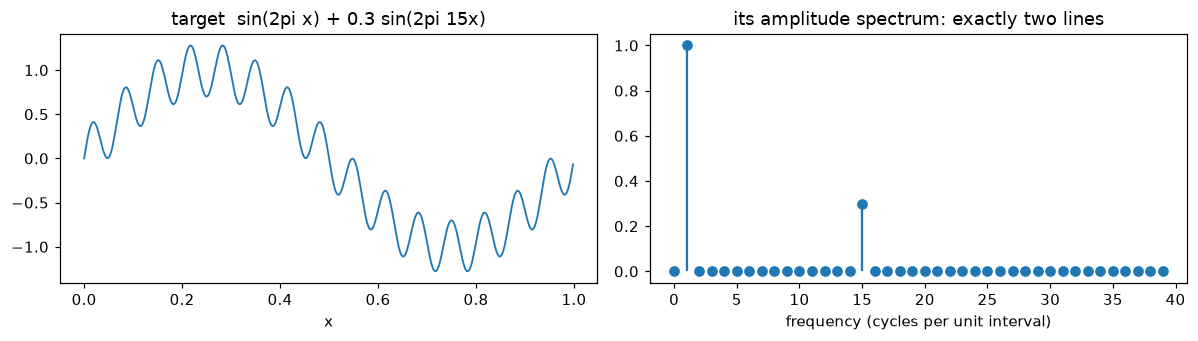

In [2]:
def target(x):
    return np.sin(2 * np.pi * 1.0 * x) + 0.3 * np.sin(2 * np.pi * 15.0 * x)

N = 512
x = np.linspace(0.0, 1.0, N, endpoint=False)
y = target(x)

def amplitude_at(signal, freq):
    # two-sided amplitude of an integer-frequency component on a uniform grid
    return 2.0 * np.abs(np.fft.rfft(signal)[freq]) / len(signal)

print(f"target amplitude at f=1  : {amplitude_at(y, 1):.4f}")
print(f"target amplitude at f=15 : {amplitude_at(y, 15):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(x, y, lw=1.2)
ax[0].set_title("target  sin(2pi x) + 0.3 sin(2pi 15x)")
ax[0].set_xlabel("x")
freqs = np.fft.rfftfreq(N, d=1.0 / N)
ax[1].stem(freqs[:40], 2 * np.abs(np.fft.rfft(y)[:40]) / N, basefmt=" ")
ax[1].set_title("its amplitude spectrum: exactly two lines")
ax[1].set_xlabel("frequency (cycles per unit interval)")
plt.tight_layout(); plt.show()

---

## 2. A plain MLP, with the backward pass written out

Two hidden ReLU layers of width 128, Adam, full-batch. The only unusual thing is that the gradients
are explicit — there is no framework to blame.

We track two numbers during training: the amplitude the network has reproduced at $f=1$ and at
$f=15$. The Frequency Principle predicts these move on very different timescales.

In [3]:
def init_mlp(d_in, width, seed):
    r = np.random.default_rng(seed)
    return {"W1": r.normal(0, np.sqrt(2.0 / d_in), (d_in, width)), "b1": np.zeros(width),
            "W2": r.normal(0, np.sqrt(2.0 / width), (width, width)), "b2": np.zeros(width),
            "W3": r.normal(0, np.sqrt(1.0 / width), (width, 1)),     "b3": np.zeros(1)}

def forward(p, z):
    h1 = np.maximum(0.0, z @ p["W1"] + p["b1"])
    h2 = np.maximum(0.0, h1 @ p["W2"] + p["b2"])
    return (h2 @ p["W3"] + p["b3"])[:, 0], (h1, h2)

def backward(p, z, cache, resid):
    h1, h2 = cache
    g = (2.0 / z.shape[0]) * resid[:, None]
    gW3, gb3 = h2.T @ g, g.sum(0)
    gh2 = (g @ p["W3"].T) * (h2 > 0)
    gW2, gb2 = h1.T @ gh2, gh2.sum(0)
    gh1 = (gh2 @ p["W2"].T) * (h1 > 0)
    return {"W1": z.T @ gh1, "b1": gh1.sum(0), "W2": gW2, "b2": gb2, "W3": gW3, "b3": gb3}

def train(p, z, y, steps, lr=1e-3, track=(1, 15), every=25):
    m = {k: np.zeros_like(v) for k, v in p.items()}
    v = {k: np.zeros_like(u) for k, u in p.items()}
    hist = []
    for t in range(1, steps + 1):
        out, cache = forward(p, z)
        resid = out - y
        g = backward(p, z, cache, resid)
        for k in p:
            m[k] = 0.9 * m[k] + 0.1 * g[k]
            v[k] = 0.999 * v[k] + 0.001 * g[k] ** 2
            p[k] -= lr * (m[k] / (1 - 0.9 ** t)) / (np.sqrt(v[k] / (1 - 0.999 ** t)) + 1e-8)
        if t == 1 or t % every == 0:
            hist.append((t, float(np.mean(resid ** 2)),
                         {f: amplitude_at(out, f) for f in track}))
    return p, hist

STEPS = 4000
p_plain, hist_plain = train(init_mlp(1, 128, 1), x[:, None], y, STEPS)
out_plain, _ = forward(p_plain, x[:, None])
mse_plain = float(np.mean((out_plain - y) ** 2))

print(f"{'step':>6} {'mse':>10} {'A(f=1)':>9} {'A(f=15)':>9}")
for t, l, a in [hist_plain[i] for i in (0, 4, 9, 39, 79, -1)]:
    print(f"{t:>6} {l:>10.5f} {a[1]:>9.4f} {a[15]:>9.4f}")
print(f"\nfinal mse {mse_plain:.6f}")
print(f"recovered {100*hist_plain[-1][2][1]/1.0:.1f}% of the f=1 amplitude "
      f"and {100*hist_plain[-1][2][15]/0.3:.1f}% of the f=15 amplitude")

  step        mse    A(f=1)   A(f=15)
     1    1.49955    0.4059    0.0271
   100    0.17842    0.6304    0.0279
   225    0.11073    0.8750    0.0260
   975    0.03887    0.9999    0.0352
  1975    0.03485    1.0015    0.0532
  4000    0.03233    1.0026    0.0767

final mse 0.032334
recovered 100.3% of the f=1 amplitude and 25.6% of the f=15 amplitude


In [4]:
# Gradient check: the hand-written backward pass against central finite differences.
# Five random entries of every parameter tensor. Two care-points that trip naive checks:
# probe at inputs away from x=0 and jitter the (zero-initialised) biases, so no ReLU
# preactivation sits exactly on its kink where a central difference straddles the corner.
rng_fd = np.random.default_rng(7)
p_fd = init_mlp(1, 16, 5)
for k in ("b1", "b2", "b3"):
    p_fd[k] = rng_fd.normal(0, 0.1, p_fd[k].shape)
z_fd, y_fd = x[40:80, None], y[40:80]
out_fd, cache_fd = forward(p_fd, z_fd)
g_fd = backward(p_fd, z_fd, cache_fd, out_fd - y_fd)

def loss_at(pp):
    o, _ = forward(pp, z_fd)
    return float(np.mean((o - y_fd) ** 2))

EPS, worst = 1e-6, 0.0
for name, tensor in p_fd.items():
    flat = tensor.reshape(-1)
    for idx in rng_fd.choice(flat.size, size=min(5, flat.size), replace=False):
        keep = flat[idx]
        flat[idx] = keep + EPS; up = loss_at(p_fd)
        flat[idx] = keep - EPS; dn = loss_at(p_fd)
        flat[idx] = keep
        num = (up - dn) / (2 * EPS)
        ana = float(g_fd[name].reshape(-1)[idx])
        worst = max(worst, abs(num - ana) / max(abs(num), abs(ana), 1e-12))
print(f"worst relative error, analytic vs finite difference "
      f"(5 entries x {len(p_fd)} tensors): {worst:.2e}")
assert worst < 1e-5, "hand-written backward pass disagrees with finite differences"
print("gradient check PASS")


worst relative error, analytic vs finite difference (5 entries x 6 tensors): 1.79e-08
gradient check PASS


### What just happened

The low tone is learned essentially exactly, and early. The high tone is still badly under-represented
after four thousand full-batch steps. The network has not run out of capacity — the width-matched control two cells below shows a plain
MLP with as many parameters as the Fourier-feature model of Section 4 failing the same way — it has
run out of *gradient* in the direction that would fix
the high-frequency error.

This is the practical shape of the Frequency Principle
([Rahaman et al., arXiv:1806.08734](https://arxiv.org/abs/1806.08734)). The printed percentages above
are the honest version of a statement everyone has seen as a blurry image.

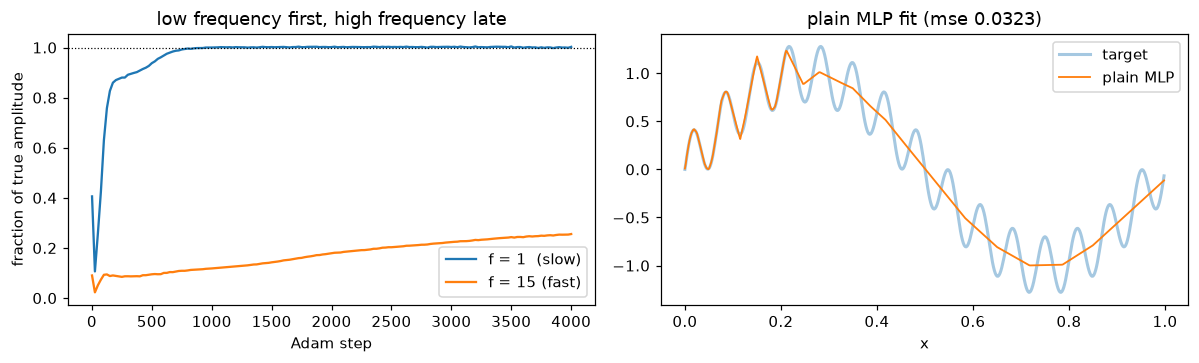

In [5]:
steps_ax = [h[0] for h in hist_plain]
a1 = [h[2][1] for h in hist_plain]
a15 = [h[2][15] for h in hist_plain]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(steps_ax, np.array(a1) / 1.0, label="f = 1  (slow)")
ax[0].plot(steps_ax, np.array(a15) / 0.3, label="f = 15 (fast)")
ax[0].axhline(1.0, color="k", ls=":", lw=0.8)
ax[0].set_xlabel("Adam step"); ax[0].set_ylabel("fraction of true amplitude")
ax[0].set_title("low frequency first, high frequency late"); ax[0].legend()
ax[1].plot(x, y, lw=2, alpha=0.4, label="target")
ax[1].plot(x, out_plain, lw=1.2, label="plain MLP")
ax[1].set_xlabel("x"); ax[1].set_title(f"plain MLP fit (mse {mse_plain:.4f})"); ax[1].legend()
plt.tight_layout(); plt.show()

In [6]:
# Capacity control: is the plain MLP failing for lack of parameters?
# The Fourier-feature model of Section 4 sees a 128-dim input, so its first weight
# matrix alone is 128x128; a width-180 plain MLP on the raw coordinate matches its
# total parameter count almost exactly. Same optimiser, steps and data.
n_128 = sum(v.size for v in init_mlp(1, 128, 1).values())
n_180 = sum(v.size for v in init_mlp(1, 180, 1).values())
n_ff  = sum(v.size for v in init_mlp(128, 128, 1).values())
print(f"parameters: width-128 plain {n_128:,} | width-180 plain {n_180:,} | Fourier-feature model {n_ff:,}")
p_wide, hist_wide = train(init_mlp(1, 180, 1), x[:, None], y, STEPS)
print(f"width-180 plain MLP at step {hist_wide[-1][0]}: "
      f"A(f=1) = {hist_wide[-1][2][1]:.4f}, A(f=15) = {hist_wide[-1][2][15]:.4f} "
      f"({100*hist_wide[-1][2][15]/0.3:.1f}% of the true 0.3)")


parameters: width-128 plain 16,897 | width-180 plain 33,121 | Fourier-feature model 33,153


width-180 plain MLP at step 4000: A(f=1) = 1.0017, A(f=15) = 0.0720 (24.0% of the true 0.3)


---

## 3. Random Fourier features, and Bochner's theorem underneath them

**Bochner's theorem.** A continuous shift-invariant function $k(x-y)$ is a positive-definite kernel
**if and only if** it is the Fourier transform of a non-negative measure. Normalise so $k(0)=1$ and that
measure is a probability distribution $p(\omega)$, which gives

$$ k(x-y) \;=\; \int p(\omega)\, e^{\,i\,\omega^{\top}(x-y)} \, d\omega \;=\; \mathbb{E}_{\omega \sim p}\!\left[\cos\!\big(\omega^{\top}(x-y)\big)\right]. $$

The right-hand side is an **expectation**, so it can be estimated by sampling. That single observation
is the whole of Rahimi and Recht's method: draw $D$ frequencies from $p$, and

$$ \varphi(x) = \sqrt{\tfrac{2}{D}}\,\big[\cos(\omega_1^{\top}x + b_1),\;\ldots,\;\cos(\omega_D^{\top}x + b_D)\big],
\qquad b_j \sim \mathrm{U}[0, 2\pi] $$

gives $\varphi(x)^{\top}\varphi(y) \approx k(x,y)$. For the RBF kernel with lengthscale $\ell$, $p$ is a
Gaussian with standard deviation $1/\ell$.

Below we measure the approximation error against the exact kernel. Monte Carlo says it should fall
like $D^{-1/2}$; we fit the slope rather than eyeballing it.

In [7]:
def rbf(X, Y, ls):
    return np.exp(-((X[:, None, :] - Y[None, :, :]) ** 2).sum(-1) / (2 * ls ** 2))

def rff(X, D, ls, rng):
    W = rng.normal(0.0, 1.0 / ls, (X.shape[1], D))
    b = rng.uniform(0.0, 2 * np.pi, D)
    return np.sqrt(2.0 / D) * np.cos(X @ W + b)

rng = np.random.default_rng(7)
n_pts, d_in, ls = 200, 4, 1.0
X = rng.normal(size=(n_pts, d_in))
K_exact = rbf(X, X, ls)

Ds = [16, 64, 256, 1024, 4096, 16384]
maxes, rmses = [], []
print(f"{'D':>7} {'max |err|':>12} {'rms err':>12} {'D^-1/2':>10}")
for D in Ds:
    errs = np.stack([np.abs(rff(X, D, ls, np.random.default_rng(1000 + t)) @
                            rff(X, D, ls, np.random.default_rng(1000 + t)).T - K_exact)
                     for t in range(5)])
    maxes.append(errs.mean(0).max()); rmses.append(np.sqrt((errs ** 2).mean()))
    print(f"{D:>7} {maxes[-1]:>12.5f} {rmses[-1]:>12.5f} {1/np.sqrt(D):>10.5f}")

slope = np.polyfit(np.log(Ds), np.log(rmses), 1)[0]
print(f"\nlog-log slope of rms error vs D : {slope:+.3f}   (Monte Carlo theory: -0.500)")
if abs(slope + 0.5) < 0.05:
    print("-> matches the D^-1/2 rate to within 0.05")
else:
    print("-> does NOT match the expected rate; investigate before trusting the section")

      D    max |err|      rms err     D^-1/2
     16      0.46363      0.22918    0.25000
     64      0.27045      0.12362    0.12500
    256      0.13427      0.06244    0.06250
   1024      0.05861      0.03043    0.03125


   4096      0.03595      0.01570    0.01562


  16384      0.01512      0.00724    0.00781

log-log slope of rms error vs D : -0.498   (Monte Carlo theory: -0.500)
-> matches the D^-1/2 rate to within 0.05


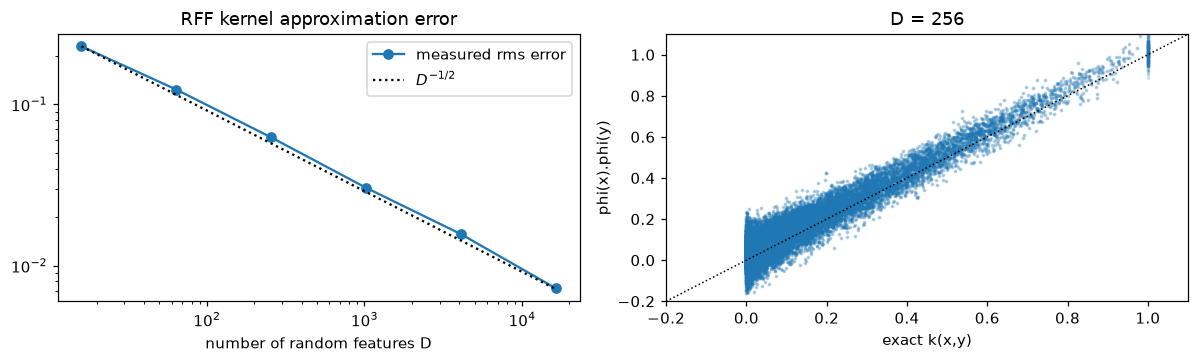

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].loglog(Ds, rmses, "o-", label="measured rms error")
ax[0].loglog(Ds, rmses[0] * (np.array(Ds) / Ds[0]) ** -0.5, "k:", label=r"$D^{-1/2}$")
ax[0].set_xlabel("number of random features D"); ax[0].legend()
ax[0].set_title("RFF kernel approximation error")
D_show = 256
P = rff(X, D_show, ls, np.random.default_rng(3))
ax[1].scatter(K_exact.ravel(), (P @ P.T).ravel(), s=2, alpha=0.15)
lims = [-0.2, 1.1]
ax[1].plot(lims, lims, "k:", lw=1)
ax[1].set_xlim(lims); ax[1].set_ylim(lims)
ax[1].set_xlabel("exact k(x,y)"); ax[1].set_ylabel("phi(x).phi(y)")
ax[1].set_title(f"D = {D_show}")
plt.tight_layout(); plt.show()

### Bochner in both directions, including the negative case

The theorem is an "if and only if", and the *only if* half is the one that earns its keep: a
shift-invariant function whose Fourier transform goes negative somewhere is **not** a kernel, no matter
how reasonable it looks. We check three things numerically:

1. the RBF's spectral density matches the closed form;
2. the Matérn-1/2 (Laplace) kernel's density is the Cauchy density, and is non-negative;
3. the **box** function — flat 1 inside a radius, 0 outside, which is exactly the similarity measure a
   novice would write down — has a $\mathrm{sinc}$ spectral density that goes negative, and therefore has
   an indefinite Gram matrix. We confirm that by computing the smallest eigenvalue directly.

In [9]:
tau = np.linspace(-8, 8, 2048)
omegas = np.linspace(-3, 3, 241)

def density(k_tau):
    # p(w) = int k(tau) e^{-2 pi i w tau} dtau, real because k is real and even
    return np.array([np.trapezoid(k_tau * np.cos(2 * np.pi * w * tau), tau) for w in omegas])

ell = 1.0
p_rbf = density(np.exp(-tau ** 2 / (2 * ell ** 2)))
p_rbf_closed = ell * np.sqrt(2 * np.pi) * np.exp(-2 * (np.pi * omegas * ell) ** 2)
p_exp = density(np.exp(-np.abs(tau) / ell))
p_exp_closed = (2 * ell) / (1 + (2 * np.pi * omegas * ell) ** 2)
p_box = density(np.where(np.abs(tau) < 1.0, 1.0, 0.0))

print(f"RBF        max |numeric - closed form| = {np.abs(p_rbf - p_rbf_closed).max():.2e}")
print(f"Matern-1/2 max |numeric - closed form| = {np.abs(p_exp - p_exp_closed).max():.2e}")
print()
print(f"min p(w),  RBF          = {p_rbf.min():+.4e}")
print(f"min p(w),  Matern-1/2   = {p_exp.min():+.4e}")
print(f"min p(w),  box function = {p_box.min():+.4f}   <- NEGATIVE")

grid = np.linspace(0, 4, 40)
K_box = np.where(np.abs(np.subtract.outer(grid, grid)) < 1.0, 1.0, 0.0)
lam = np.linalg.eigvalsh(K_box).min()
print(f"\nsmallest eigenvalue of the box Gram matrix (40x40) = {lam:+.4f}")
print("Bochner said so before we built the matrix." if lam < -1e-8 else
      "unexpected: the Gram matrix came out PSD; re-check the grid spacing")

RBF        max |numeric - closed form| = 3.11e-15
Matern-1/2 max |numeric - closed form| = 6.76e-04

min p(w),  RBF          = -1.9082e-15
min p(w),  Matern-1/2   = +5.6062e-03
min p(w),  box function = -0.4338   <- NEGATIVE

smallest eigenvalue of the box Gram matrix (40x40) = -3.4230
Bochner said so before we built the matrix.


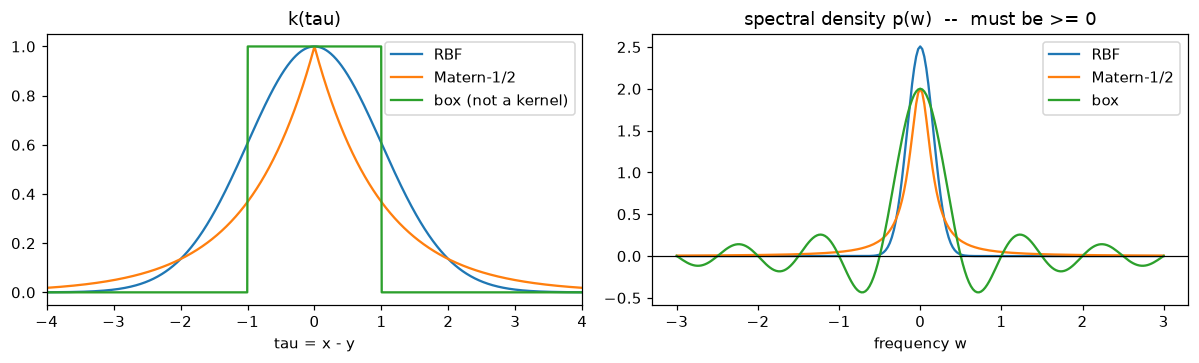

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(tau, np.exp(-tau ** 2 / 2), label="RBF")
ax[0].plot(tau, np.exp(-np.abs(tau)), label="Matern-1/2")
ax[0].plot(tau, np.where(np.abs(tau) < 1, 1.0, 0.0), label="box (not a kernel)")
ax[0].set_xlim(-4, 4); ax[0].set_xlabel("tau = x - y"); ax[0].set_title("k(tau)"); ax[0].legend()
ax[1].plot(omegas, p_rbf, label="RBF")
ax[1].plot(omegas, p_exp, label="Matern-1/2")
ax[1].plot(omegas, p_box, label="box")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("frequency w"); ax[1].set_title("spectral density p(w)  --  must be >= 0"); ax[1].legend()
plt.tight_layout(); plt.show()

### Designing in the spectrum: the spectral mixture kernel

Once kernels and densities are the same object, kernel *design* becomes density design, which is much
easier because densities are things you can draw. Put a Gaussian bump at $\omega = 1.5$ and you have
asked for structure that repeats with period $1/1.5$; the corresponding kernel comes out of the
inverse transform without you having to invent it.

([Wilson & Adams, ICML 2013](https://proceedings.mlr.press/v28/wilson13.html) is the reference.)

designed component means : [0.0, 1.5]
two tallest peaks found  : [0.  1.5]

The smaller ripples either side are spectral leakage from truncating tau to [-8, 8].
A finite window in one domain is a convolution with a sinc in the other -- the
uncertainty principle, showing up as a measurement artefact rather than as a theorem.


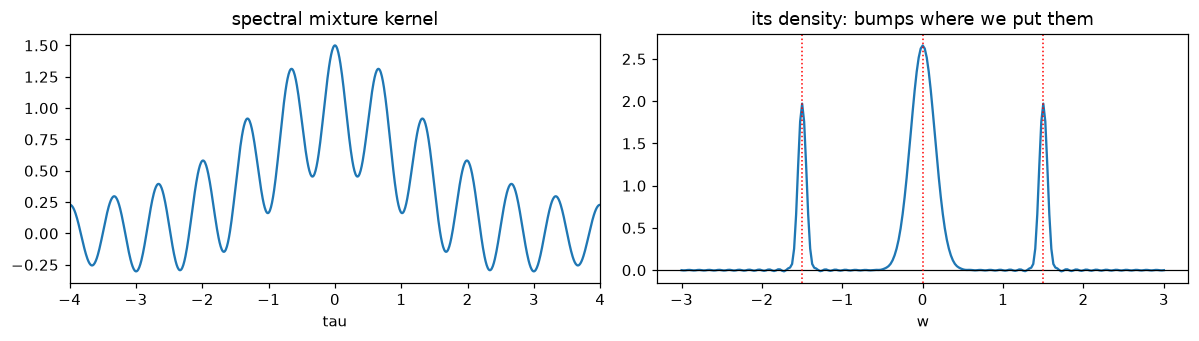

In [11]:
def sm_kernel(tau, weights, means, stds):
    k = np.zeros_like(tau)
    for w, mu, s in zip(weights, means, stds):
        k += w * np.exp(-2 * (np.pi * s * tau) ** 2) * np.cos(2 * np.pi * mu * tau)
    return k

MEANS = [0.0, 1.5]
k_sm = sm_kernel(tau, [1.0, 0.5], MEANS, [0.15, 0.05])
p_sm = density(k_sm)

is_peak = (p_sm[1:-1] > p_sm[:-2]) & (p_sm[1:-1] > p_sm[2:])
cand = omegas[1:-1][is_peak]
heights = p_sm[1:-1][is_peak]
top2 = np.sort(cand[np.argsort(heights)[-2:]])
print(f"designed component means : {MEANS}")
print(f"two tallest peaks found  : {np.round(np.abs(top2)[np.argsort(np.abs(top2))], 3)}")
print("\nThe smaller ripples either side are spectral leakage from truncating tau to [-8, 8].")
print("A finite window in one domain is a convolution with a sinc in the other -- the")
print("uncertainty principle, showing up as a measurement artefact rather than as a theorem.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(tau, k_sm); ax[0].set_xlim(-4, 4); ax[0].set_xlabel("tau"); ax[0].set_title("spectral mixture kernel")
ax[1].plot(omegas, p_sm); ax[1].axhline(0, color="k", lw=0.8)
for mu in MEANS:
    ax[1].axvline(mu, color="r", ls=":", lw=1)
    if mu: ax[1].axvline(-mu, color="r", ls=":", lw=1)
ax[1].set_xlabel("w"); ax[1].set_title("its density: bumps where we put them")
plt.tight_layout(); plt.show()

---

## 4. The same MLP, with a Fourier feature map in front

Now the payoff. We change **nothing** about the network, the optimiser, the step count or the data.
We only replace the input $x$ with

$$ \gamma(x) = \big[\cos(2\pi B x),\; \sin(2\pi B x)\big], \qquad B_j \sim \mathcal{N}(0, \sigma^2). $$

This is the positional encoding from
[Tancik et al. (arXiv:2006.10739)](https://arxiv.org/abs/2006.10739), which is the NeRF encoding with
the frequencies sampled instead of laid out in octaves.

In [12]:
def rff_map(x, B):
    proj = 2 * np.pi * x[:, None] * B[None, :]
    return np.concatenate([np.cos(proj), np.sin(proj)], axis=1)

SIGMA = 10.0
B = np.random.default_rng(0).normal(0.0, SIGMA, 64)
z_ff = rff_map(x, B)

p_ff, hist_ff = train(init_mlp(z_ff.shape[1], 128, 1), z_ff, y, STEPS)
out_ff, _ = forward(p_ff, z_ff)
mse_ff = float(np.mean((out_ff - y) ** 2))

print(f"{'step':>6} {'mse':>12} {'A(f=1)':>9} {'A(f=15)':>9}")
for t, l, a in [hist_ff[i] for i in (0, 4, 9, 39, -1)]:
    print(f"{t:>6} {l:>12.8f} {a[1]:>9.4f} {a[15]:>9.4f}")

print(f"\n              plain MLP      Fourier-feature MLP")
print(f"final mse   {mse_plain:>10.6f}   {mse_ff:>18.3e}")
print(f"A(f=15)     {hist_plain[-1][2][15]:>10.4f}   {hist_ff[-1][2][15]:>18.4f}    (true 0.3000)")
print(f"\nhigh-frequency amplitude recovered: "
      f"{100*hist_plain[-1][2][15]/0.3:.1f}% -> {100*hist_ff[-1][2][15]/0.3:.1f}%")
print("\nNote the Fourier-feature loss column: it bottoms out in the 1e-7 range around a")
print("thousand steps, then wanders back up into the 1e-4 range while the fit stays visibly")
print("perfect -- full-batch Adam with a fixed step size overshooting in a nearly flat basin,")
print("not the model forgetting. The loss also bounces step to step at that depth, which is")
print("why the final-mse line and the step-4000 table row differ. The amplitude recovery is")
print("the statistic to read here; the loss has stopped being one.")

  step          mse    A(f=1)   A(f=15)
     1   0.62005206    0.2424    0.0795
   100   0.00005931    1.0011    0.3007
   225   0.00000998    1.0000    0.3000
   975   0.00000033    1.0000    0.3000
  4000   0.00026136    1.0007    0.2993

              plain MLP      Fourier-feature MLP
final mse     0.032334            4.504e-04
A(f=15)         0.0767               0.2993    (true 0.3000)

high-frequency amplitude recovered: 25.6% -> 99.8%

Note the Fourier-feature loss column: it bottoms out in the 1e-7 range around a
thousand steps, then wanders back up into the 1e-4 range while the fit stays visibly
perfect -- full-batch Adam with a fixed step size overshooting in a nearly flat basin,
not the model forgetting. The loss also bounces step to step at that depth, which is
why the final-mse line and the step-4000 table row differ. The amplitude recovery is
the statistic to read here; the loss has stopped being one.


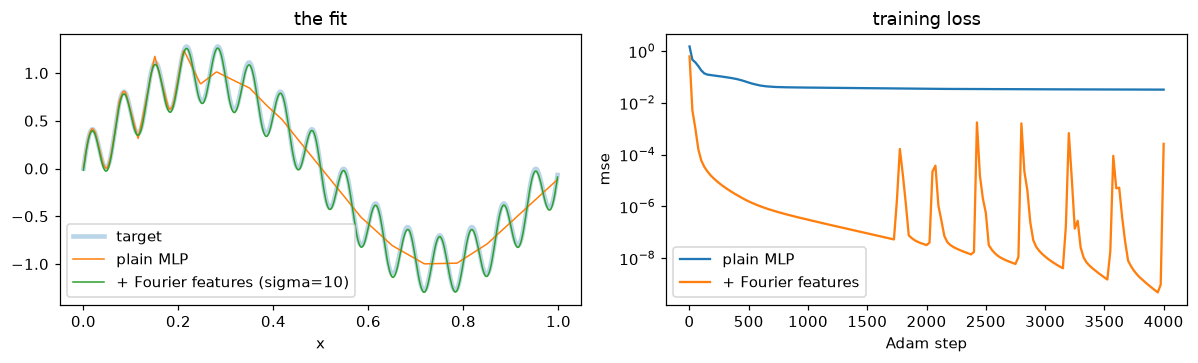

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(x, y, lw=3, alpha=0.3, label="target")
ax[0].plot(x, out_plain, lw=1.0, label="plain MLP")
ax[0].plot(x, out_ff, lw=1.0, label=f"+ Fourier features (sigma={SIGMA:g})")
ax[0].set_xlabel("x"); ax[0].legend(); ax[0].set_title("the fit")
ax[1].semilogy([h[0] for h in hist_plain], [h[1] for h in hist_plain], label="plain MLP")
ax[1].semilogy([h[0] for h in hist_ff], [np.maximum(h[1], 1e-14) for h in hist_ff],
               label="+ Fourier features")
ax[1].set_xlabel("Adam step"); ax[1].set_ylabel("mse"); ax[1].legend(); ax[1].set_title("training loss")
plt.tight_layout(); plt.show()

---

## 5. Why it works: the neural tangent kernel, measured

The explanation is not "more features". It is that **an MLP trained by gradient descent behaves, in the
wide limit, like kernel regression with its neural tangent kernel**, and the feature map changes that
kernel.

For a one-hidden-layer net $f(z) = \tfrac{1}{\sqrt m}\sum_r a_r\,\mathrm{relu}(w_r^{\top}z + c_r)$ the NTK
is $\Theta(z,z') = \nabla_\theta f(z)^{\top}\nabla_\theta f(z')$, which we can write out exactly:

$$ \Theta(z,z') = \tfrac1m\sum_r \mathrm{relu}(u_r)\mathrm{relu}(u'_r)
   \;+\; \tfrac1m\sum_r a_r^2\,\mathbb{1}[u_r>0]\,\mathbb{1}[u'_r>0]\,(z^{\top}z' + 1), \qquad u_r = w_r^{\top}z + c_r. $$

No autodiff needed. Two honesty notes before the numbers. First, this one-hidden-layer form is an
analytic **proxy** for the two-hidden-layer network we actually trained — same activation, same input
geometry, evaluated at initialisation. It shows the mechanism in miniature; it is not the trained
model's exact kernel. Second, we evaluate it on the unit-normalised map $\gamma(x)/\sqrt{D}$ so its
entries sit at the same $O(1)$ scale as the raw coordinate; training consumed the unnormalised map.

We evaluate the kernel on $x \in [0,1]$ two ways — on the raw coordinate, and on
$\gamma(x)$ — and measure two properties:

- **Stationarity.** A stationary kernel depends only on $x-x'$, so it is constant along each diagonal of
  the $(x,x')$ grid. We report the mean within-diagonal standard deviation, normalised by the kernel's
  own scale: 0 is perfectly stationary.
- **Width.** How far apart two inputs must be before the kernel has fallen to half its peak. This is the
  scale over which the model is forced to be smooth, so it is an upper bound on the detail it can fit.

In [14]:
def ntk(Z, m_units, seed):
    r = np.random.default_rng(seed)
    W = r.normal(0, 1, (Z.shape[1], m_units))
    c = r.normal(0, 1, m_units)
    a = r.normal(0, 1, m_units)
    U = Z @ W + c
    R = np.maximum(U, 0.0)
    H = (U > 0).astype(float)
    return (R @ R.T) / m_units + ((H * a) @ (H * a).T) / m_units * (Z @ Z.T + 1.0)

def stationarity_error(K):
    devs, wts = [], []
    n = K.shape[0]
    for k in range(-(n - 1), n):
        dg = np.diagonal(K, offset=k)
        if len(dg) >= 8:
            devs.append(dg.std()); wts.append(len(dg))
    return float(np.average(devs, weights=wts) / K.std())

def half_width(K, xs):
    prof = np.array([np.diagonal(K, offset=k).mean() for k in range(K.shape[0])])
    prof = (prof - prof.min()) / (prof.max() - prof.min())
    idx = int(np.argmax(prof < 0.5))
    return xs[idx] - xs[0] if idx > 0 else np.nan

xs = np.linspace(0, 1, 128)
grid_step = xs[1] - xs[0]
K_raw = ntk(xs[:, None], 8192, 3)
K_ff = ntk(rff_map(xs, B) / np.sqrt(len(B)), 8192, 3)

print(f"{'input':>18} {'stationarity err':>18} {'half-width':>12}")
print(f"{'raw coordinate x':>18} {stationarity_error(K_raw):>18.4f} {half_width(K_raw, xs):>12.4f}")
print(f"{'gamma(x)':>18} {stationarity_error(K_ff):>18.4f} {half_width(K_ff, xs):>12.4f}")
print(f"\ngrid resolution = {grid_step:.4f}; the target's f=15 component has period {1/15:.4f}")
print(f"the raw-coordinate NTK is {half_width(K_raw, xs)*15:.1f} periods of that component wide,")
print(f"so it cannot resolve it. gamma(x) brings it to {half_width(K_ff, xs)*15:.2f} periods.")

             input   stationarity err   half-width
  raw coordinate x             0.8486       0.5354
          gamma(x)             0.0864       0.0236

grid resolution = 0.0079; the target's f=15 component has period 0.0667
the raw-coordinate NTK is 8.0 periods of that component wide,
so it cannot resolve it. gamma(x) brings it to 0.35 periods.


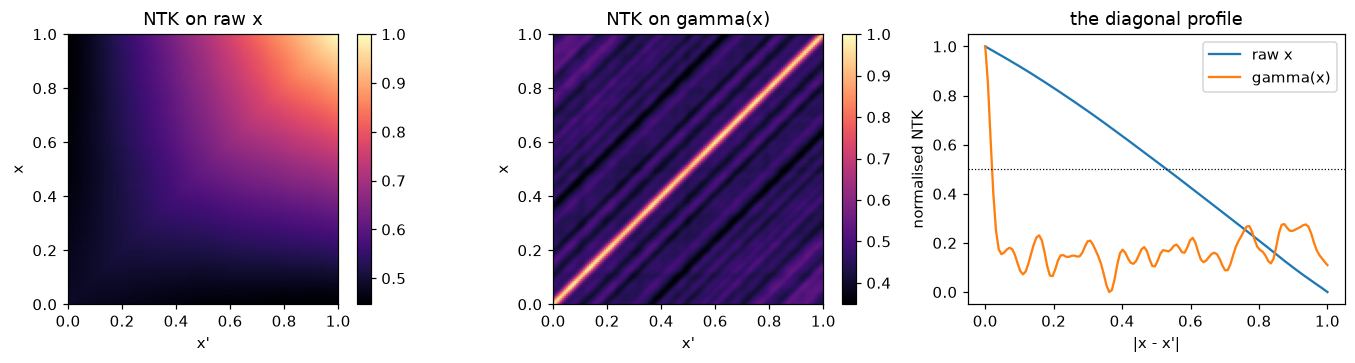

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a_, K, t in [(ax[0], K_raw, "NTK on raw x"), (ax[1], K_ff, "NTK on gamma(x)")]:
    im = a_.imshow(K / K.max(), origin="lower", extent=[0, 1, 0, 1], cmap="magma")
    a_.set_title(t); a_.set_xlabel("x'"); a_.set_ylabel("x")
    plt.colorbar(im, ax=a_, fraction=0.046)
for K, lab in [(K_raw, "raw x"), (K_ff, "gamma(x)")]:
    prof = np.array([np.diagonal(K, offset=k).mean() for k in range(K.shape[0])])
    ax[2].plot(xs - xs[0], (prof - prof.min()) / (prof.max() - prof.min()), label=lab)
ax[2].axhline(0.5, color="k", ls=":", lw=0.8)
ax[2].set_xlabel("|x - x'|"); ax[2].set_ylabel("normalised NTK"); ax[2].legend()
ax[2].set_title("the diagonal profile")
plt.tight_layout(); plt.show()

The left panel is the picture worth keeping. The raw-coordinate NTK is a broad, lopsided blob: similarity
between two inputs depends on **where** they are, not just how far apart, and it stays high across most of
the domain. Regression under that kernel is heavily smoothed by construction.

The $\gamma(x)$ NTK is a narrow band along the diagonal. It is (nearly) stationary, and its width is small
compared with the period of the component the plain network could not fit.

### The scale knob, and where the measurement stops working

$\sigma$ — the standard deviation of the sampled frequencies — is the dial. Larger $\sigma$ means a narrower
NTK, which means more capacity for detail and less implicit smoothing. This is the entire content of the
"choose your positional-encoding bandwidth" problem, and it is why that hyperparameter is so much more
sensitive than its appearance suggests.

The sweep below also shows its own floor, which is worth printing rather than hiding.

In [16]:
print(f"{'sigma':>8} {'half-width':>12} {'stationarity err':>18} {'note':>28}")
floor = grid_step
for sigma in [1.0, 3.0, 10.0, 30.0, 100.0]:
    Bs = np.random.default_rng(0).normal(0, sigma, 64)
    Ks = ntk(rff_map(xs, Bs) / np.sqrt(len(Bs)), 4096, 3)
    hw = half_width(Ks, xs)
    note = "at the sampling floor" if hw <= floor + 1e-12 else ""
    print(f"{sigma:>8.1f} {hw:>12.4f} {stationarity_error(Ks):>18.4f} {note:>28}")

print(f"\nThe grid spacing is {floor:.4f}. Once the NTK is one grid step wide the measurement")
print("bottoms out: we cannot resolve a kernel narrower than our own sampling, which is the")
print("Nyquist limit applied to the diagnostic rather than to the model. Two different sigmas")
print("printing the same half-width here does NOT mean they train the same way -- it means")
print("this probe has stopped discriminating, and a finer grid is needed to tell them apart.")

   sigma   half-width   stationarity err                         note
     1.0       0.1890             0.0419                             
     3.0       0.0630             0.0575                             
    10.0       0.0236             0.1104                             


    30.0       0.0079             0.1884        at the sampling floor
   100.0       0.0079             0.1994        at the sampling floor

The grid spacing is 0.0079. Once the NTK is one grid step wide the measurement
bottoms out: we cannot resolve a kernel narrower than our own sampling, which is the
Nyquist limit applied to the diagnostic rather than to the model. Two different sigmas
printing the same half-width here does NOT mean they train the same way -- it means
this probe has stopped discriminating, and a finer grid is needed to tell them apart.


> **Engineering callout #1 — a saturating diagnostic looks exactly like a converged one.**
>
> The half-width column stops moving above $\sigma \approx 30$. The tempting reading is "returns
> diminish past 30, so stop tuning there." The actual reason is that the statistic is computed on a
> 128-point grid and cannot report a width below one grid step. The failure and the finding print
> identically.
>
> The general form of this: whenever a measured quantity flattens at exactly the resolution of the
> instrument, the instrument is the thing you are measuring. Print the floor next to the value — one
> line of code — and the ambiguity disappears.

> **Engineering callout #2 — the scale is a prior, and over-scaling is a real failure.**
>
> It is tempting to read "larger $\sigma$ narrows the NTK, and a narrow NTK fits detail" as "set
> $\sigma$ large." It is not. A kernel much narrower than the structure in your data fits the noise
> between your samples: the model interpolates the training points and oscillates wildly between them.
> Tancik et al. report exactly this as a tuning curve with an interior optimum, and the diagnostic is
> in the flagship — compare the **power spectrum** of your predictions against the target. Under-scaled
> $\sigma$ shows too little high-frequency energy; over-scaled shows too much. Aggregate error cannot
> distinguish them.

---

## 6. What to take away

- **Spectral bias is measurable in about twenty lines.** Track the amplitude of known frequency
  components during training instead of watching a scalar loss. Our plain MLP reached the low tone
  essentially exactly and the high tone at roughly a quarter of its true amplitude, climbing so slowly
  that closing the gap is a matter of orders of magnitude more steps, not patience.
- **Random Fourier features are Bochner's theorem plus Monte Carlo**, and the error falls at the
  predicted $D^{-1/2}$ rate — we fit the slope rather than trusting the shape of the curve.
- **Bochner is an iff, and the reverse direction has teeth.** The box similarity function is not a
  kernel, and the negative spectral density predicts the indefinite Gram matrix before you build it.
- **The feature map works by changing the model's implicit kernel** from broad and non-stationary to
  narrow and stationary. This is not an analogy — the NTK is computable in closed form for a
  one-hidden-layer proxy of this architecture, and the two properties are two printed numbers.
- **The feature scale is a bandwidth prior**, and the honest way to tune it is with a spectral
  comparison of predictions against ground truth, not with MSE.

Next: **[NB 01 — FNet vs Attention vs GP Attention](01_fnet_vs_attention_vs_gpa.ipynb)** takes the kernel
view one step further and asks what happens when you replace a mixing layer with an FFT.

**Further reading.** [Random Features for Large-Scale Kernel Machines (Rahimi & Recht, 2007)](https://papers.nips.cc/paper_files/paper/2007/hash/013a006f03dbc5392effeb8f18fda755-Abstract.html) ·
[On the Spectral Bias of Neural Networks (arXiv:1806.08734)](https://arxiv.org/abs/1806.08734) ·
[Fourier Features Let Networks Learn High Frequency Functions (arXiv:2006.10739)](https://arxiv.org/abs/2006.10739) ·
[Gaussian Process Kernels for Pattern Discovery and Extrapolation (Wilson & Adams, 2013)](https://proceedings.mlr.press/v28/wilson13.html)

Our earlier weeks this notebook leans on:
[3D Gaussian Splatting explained](https://artifocial.com/blog/gaussian-splatting-explained-2026-apr-03) ·
[Attention is a kernel](https://artifocial.com/blog/attention-is-a-kernel-2026-jul-12) ·
[Gaussian processes explained](https://artifocial.com/blog/gaussian-processes-explained-2026-jul-13)